# Importing libraries and extracting dataset


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Flatten,Dropout, Conv2D, MaxPooling2D,BatchNormalization
import warnings
warnings.filterwarnings('ignore')

**Loading dataset into directory and extracting the zip file**

**Loading the directory into a dataframe**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os
import zipfile
dataset_path = "/content/drive/MyDrive/animal_data.zip"
dir = "animal_data"  # Directory to extract to

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(dir)

# Update dataset path to the extracted directory
data= os.path.join(dir, 'animal_data')

In [14]:
import pandas as pd
from glob import glob
df = pd.DataFrame({"path":[],"label":[]}) #dataframe for training data
label_list = ['Bear','Bird','Cat','Cow','Deer','Dog','Dolphin','Elephant','Giraffe','Horse','Kangaroo','Lion','Panda','Tiger','Zebra']
#label_list=os.listdir(data)

for i, label in enumerate(label_list):
    img_path = os.path.join(data, label)
    img_list = glob(img_path+'/*.jpg')
    for img in img_list:
        new_data =pd.DataFrame({"path":img,"label":label}, index=[1])
        df = pd.concat([df, new_data], ignore_index=True)   #adding each image with its label to the dataframe

df[["path"]] = df[["path"]].astype(str)
df[["label"]] = df[["label"]].astype(str)


# Overview of the dataset

In [16]:
df.head()

,path,label
0,animal_data/animal_data/Bear/Bear_7_3.jpg,Bear
1,animal_data/animal_data/Bear/Bear_9_2.jpg,Bear
2,animal_data/animal_data/Bear/bear_8_1.jpg,Bear
3,animal_data/animal_data/Bear/Bear_15_2.jpg,Bear
4,animal_data/animal_data/Bear/Bear_10_2.jpg,Bear


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1646 entries, 0 to 1645
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    1646 non-null   object
 1   label   1646 non-null   object
dtypes: object(2)
memory usage: 25.8+ KB


<Axes: xlabel='count', ylabel='label'>

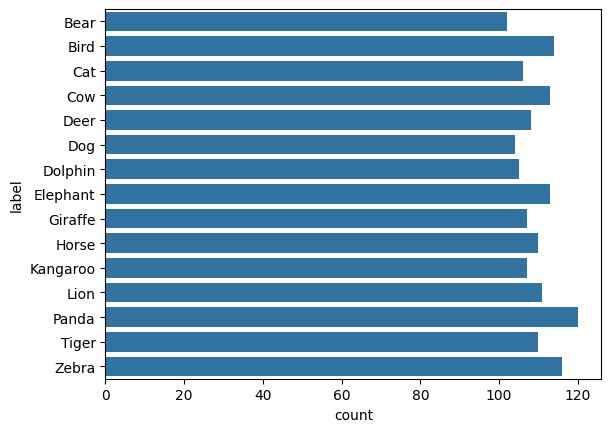

In [18]:
sns.countplot(df['label'])

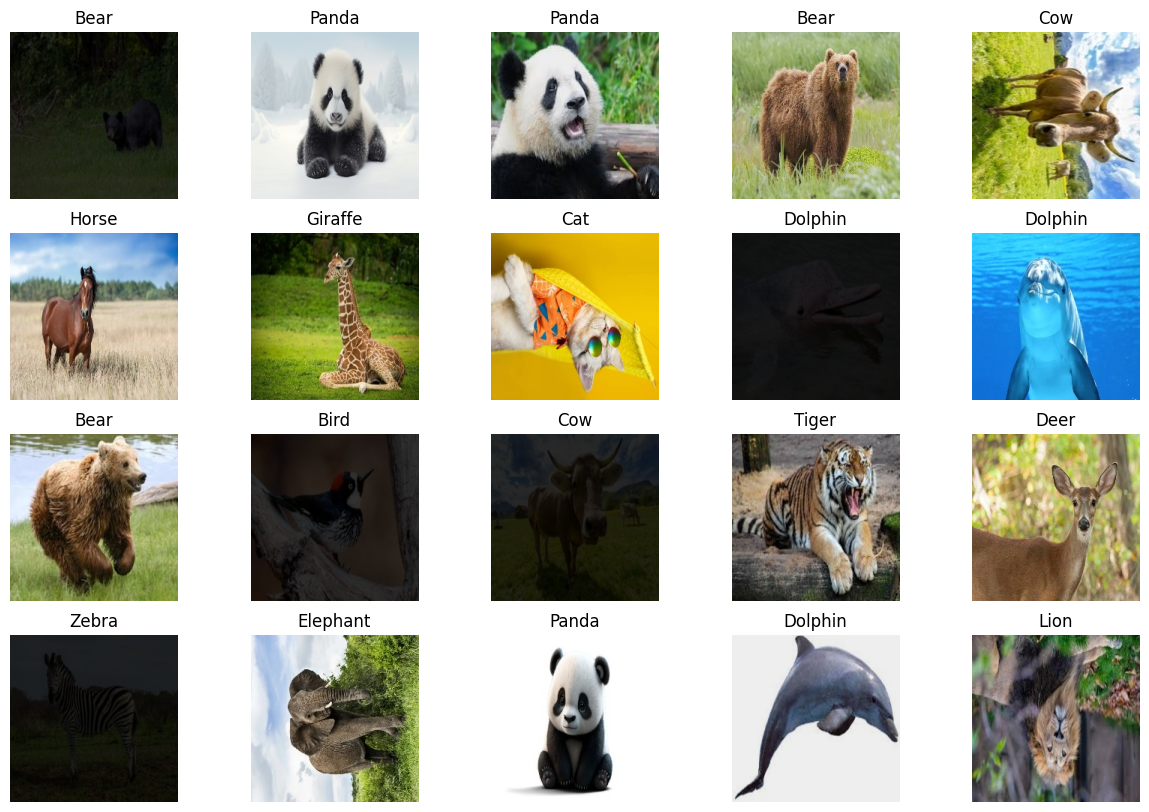

In [22]:
# visualization of some data in the dataset
show_imgs = 20
idx = np.random.randint(0, len(df),size=show_imgs)
fig, axes = plt.subplots(show_imgs//5, 5, figsize=(15,10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    full_path = df.loc[idx[i]]['path']
    ax.imshow(plt.imread(full_path))
    ax.set_title(df.loc[idx[i]]['label'])
    ax.set_axis_off()

# Splitting,Preprocessing and Encoding

In [23]:
X=df['path']
y=df['label']

In [27]:
X

array([[[[0.88235295, 0.92156863, 0.91764706],
         [0.8862745 , 0.9254902 , 0.92156863],
         [0.8901961 , 0.92941177, 0.9254902 ],
         ...,
         [0.26666668, 0.3137255 , 0.27450982],
         [0.26666668, 0.30980393, 0.2784314 ],
         [0.5411765 , 0.58431375, 0.5686275 ]],

        [[0.88235295, 0.92156863, 0.91764706],
         [0.8862745 , 0.9254902 , 0.92156863],
         [0.89411765, 0.93333334, 0.92941177],
         ...,
         [0.08627451, 0.13333334, 0.09411765],
         [0.30588236, 0.34901962, 0.31764707],
         [0.5803922 , 0.62352943, 0.6       ]],

        [[0.88235295, 0.92156863, 0.91764706],
         [0.8901961 , 0.92941177, 0.9254902 ],
         [0.89411765, 0.93333334, 0.92941177],
         ...,
         [0.44705883, 0.49411765, 0.45490196],
         [0.23921569, 0.28235295, 0.2509804 ],
         [0.5058824 , 0.54901963, 0.5254902 ]],

        ...,

        [[0.4392157 , 0.52156866, 0.45490196],
         [0.49019608, 0.57254905, 0.5058824 ]

**Preprocessing images**

In [40]:
import numpy as np

# X is already a NumPy array of images with values between 0 and 1
# We just need to ensure the data type is float32 for Keras models
# and potentially ensure the axes are in the correct format (Channels Last is default for Keras)

def preprocess_data(X):
    # Ensure data type is float32
    if X.dtype != np.float32:
        X = X.astype(np.float32)

    # If X is 4D (Batch, Height, Width, Channels) it is ready.
    # If X is 3D (Height, Width, Channels) and represents a single image,
    # you might need to add a batch dimension: X = np.expand_dims(X, axis=0)

    # Optional: Ensure values are strictly between 0 and 1 (though they look correct in your sample)
    # X = np.clip(X, 0.0, 1.0)

    return X

X = preprocess_data(X)

### Data Before Preprocessing (Image Paths)

Before loading the images and processing their pixel values, the `X` variable contained the file paths to each image from the DataFrame. Here's how it looked:

In [41]:
display(df['path'].head())

,path
0,animal_data/animal_data/Bear/Bear_7_3.jpg
1,animal_data/animal_data/Bear/Bear_9_2.jpg
2,animal_data/animal_data/Bear/bear_8_1.jpg
3,animal_data/animal_data/Bear/Bear_15_2.jpg
4,animal_data/animal_data/Bear/Bear_10_2.jpg


### Data After Preprocessing (NumPy Array of Image Data)

After preprocessing, the `X` variable is a NumPy array where each element is a numerical representation of an image. Each image is typically resized (e.g., to 96x96 pixels), converted into a NumPy array, and its pixel values are normalized (usually scaled between 0 and 1).

Here's an example of the first preprocessed image array:

In [42]:
print(X[0])
print(f"Shape of preprocessed data: {X.shape}")
print(f"Data type of preprocessed data: {X.dtype}")

[[[0.88235295 0.92156863 0.91764706]
  [0.8862745  0.9254902  0.92156863]
  [0.8901961  0.92941177 0.9254902 ]
  ...
  [0.26666668 0.3137255  0.27450982]
  [0.26666668 0.30980393 0.2784314 ]
  [0.5411765  0.58431375 0.5686275 ]]

 [[0.88235295 0.92156863 0.91764706]
  [0.8862745  0.9254902  0.92156863]
  [0.89411765 0.93333334 0.92941177]
  ...
  [0.08627451 0.13333334 0.09411765]
  [0.30588236 0.34901962 0.31764707]
  [0.5803922  0.62352943 0.6       ]]

 [[0.88235295 0.92156863 0.91764706]
  [0.8901961  0.92941177 0.9254902 ]
  [0.89411765 0.93333334 0.92941177]
  ...
  [0.44705883 0.49411765 0.45490196]
  [0.23921569 0.28235295 0.2509804 ]
  [0.5058824  0.54901963 0.5254902 ]]

 ...

 [[0.4392157  0.52156866 0.45490196]
  [0.49019608 0.57254905 0.5058824 ]
  [0.4117647  0.49411765 0.42745098]
  ...
  [0.18039216 0.24313726 0.20392157]
  [0.19607843 0.25882354 0.21960784]
  [0.16862746 0.22745098 0.2       ]]

 [[0.47058824 0.5529412  0.47843137]
  [0.4627451  0.54509807 0.47058824]


**Encoding the labels of images**

In [44]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Re-initialize y with the original labels from the DataFrame
y = df['label']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = to_categorical(y, 15)

**Splitting the dataset**

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.2,random_state=102,shuffle=True)
X_test,X_val,y_test,y_val=train_test_split(X_temp,y_temp,test_size=0.2,random_state=102,shuffle=True)

# Defining Model

In [46]:
model=keras.Sequential([
    Conv2D(filters=16,kernel_size=3,input_shape=(96,96,3),padding="same",activation='relu'),
    MaxPooling2D(pool_size=2),
    #Dropout(0.25),

    Conv2D(filters=32,kernel_size=3,padding="same",activation='relu'),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(15,activation='softmax')
])

In [47]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,775 (4.52 MB)

 Trainable params: 1,185,775 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model**

In [48]:
history=model.fit(X_train, y_train, epochs=50,validation_data=(X_val,y_val))

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.0988 - loss: 2.7110 - val_accuracy: 0.2121 - val_loss: 2.5694
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1527 - loss: 2.5546 - val_accuracy: 0.2727 - val_loss: 2.4224
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2090 - loss: 2.4132 - val_accuracy: 0.2727 - val_loss: 2.2732
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2819 - loss: 2.2620 - val_accuracy: 0.3333 - val_loss: 2.2300
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3176 - loss: 2.1171 - val_accuracy: 0.3030 - val_loss: 2.1136
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3777 - loss: 1.9570 - val_accuracy: 0.3788 - val_loss: 1.9920
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4377 - loss: 1.7757 - val_accuracy: 0.3939 - val_loss: 1.9564
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4848 - loss: 1.6119 - val_accuracy: 0.5152 - val_los

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7045 - loss: 2.1486
Loss =  2.1485791206359863
Accuracy =  70.45454382896423 %


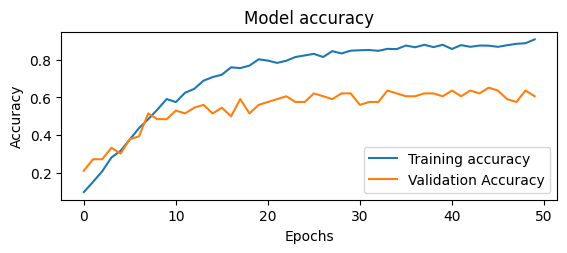

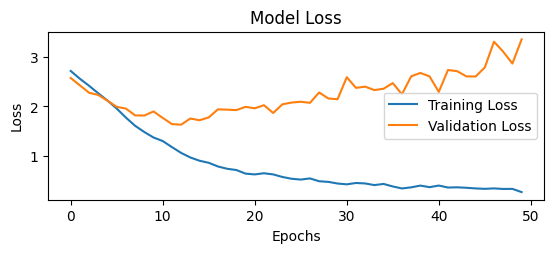

In [49]:
#Loss and accuracy on testing data
results = model.evaluate(X_test,y_test)
print("Loss = ",results[0])
print("Accuracy = ",results[1]*100,"%")

#plotting training and validation accuracy vs epochs
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#plotting training and validation loss vs epochs
plt.subplot(2,1,2)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Sample Output

label: 
Dog                            Giraffe                            Cat                            Cow                            Dog                            

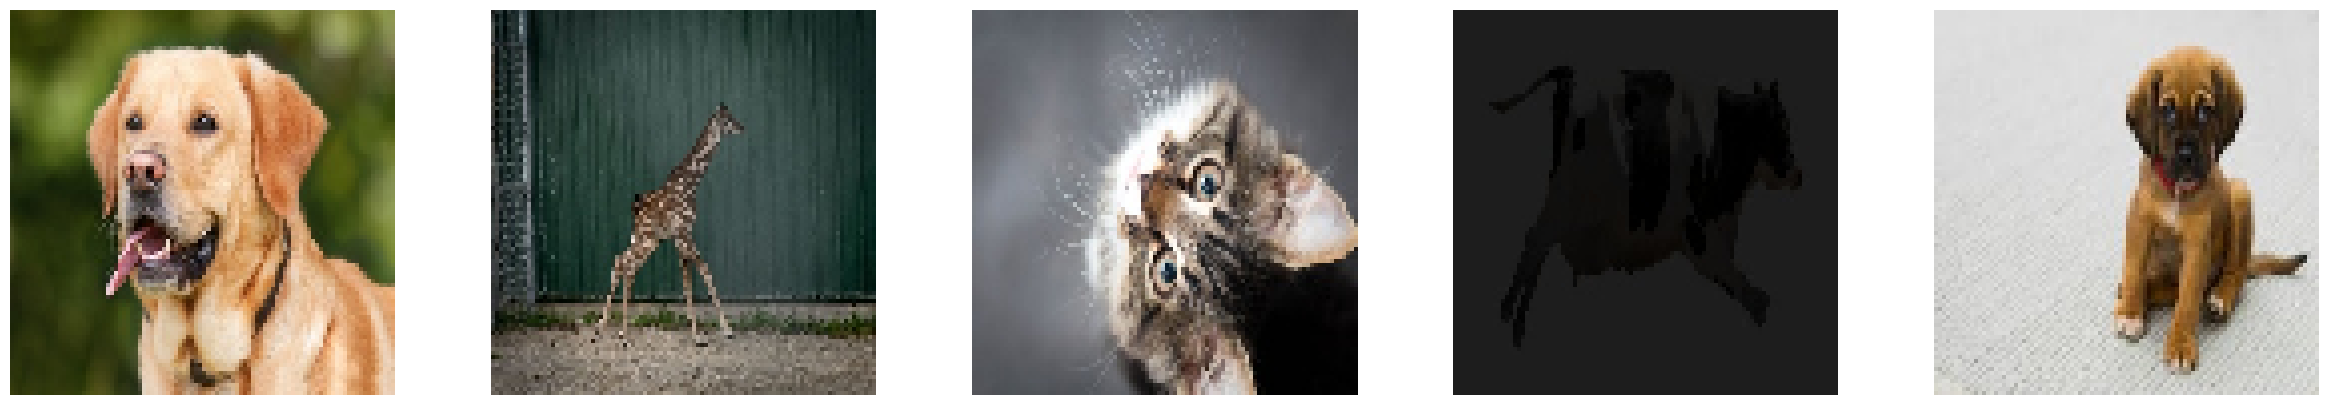

Predicted value: 
Dog                           Giraffe                           Giraffe                           Cow                           Dog                           

In [50]:
n = 5   # = no. of images to see predictions on

index = np.random.choice(X_test.shape[0],n)  # choose random index from test data
print("label: ")
fig, axes = plt.subplots(1, n, figsize=(30, 5))

for i,ind in enumerate(index):
    plt.subplot(1,n,i+1)
    plt.imshow(X_test[ind])
    plt.axis("off")
    print(label_list[np.argmax(y_test[ind])],end="                            ")

plt.show()
print("Predicted value: ")

# printing the predictions

for i,ind in enumerate(index):
    prob = model.predict(X_test[ind].reshape(1,96,96,3),verbose=0)[0]
    label = label_list[np.argmax(prob)]
    print(label,end="                           ")